In [1]:
# Parameters
param1=1

In [2]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy


from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, create_data
from utils import cosine_similarity, get_r_2, vector_angle, factorize_matrix
from tqdm import tqdm
from tqdm import tqdm
from utils import alignment_score, calc_PR, calc_NC1
import matplotlib as mpl
from functools import reduce



/home/avivra/PycharmProjects/RepresentationShaping/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [4]:
C = Config()

C.G = 0.8
C.sig_h_2 = 1e-5
# C.gpu_id=1
# C.seed = 1
C.linear_net = True
C.split_actions = True
# C.allow_backwards = True
C.learning_rate = 0.01
C.L=5
C.print_progress = True
C.length_corridors = [10]*1
# C.input_size = 100
C.max_move = 5
C.hidden_size = (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs *= 100
C.algo_name = 'SGD'
C.loss_fn = nn.MSELoss()
C.bias = False
C.egocentric_movement = True
C.lambda_reg = 0
C.B = 1
C.label_noise = 0.1
# C.whiten_data = True
# C.fixed_output = False
# C.split_actions = False
# C.allow_backwards = True

# C.min_move = 2
# C.one_hot_actions = True
# C.one_hot_inputs = False

In [5]:

C = Config()
C.num_epochs = 1
C.length_corridors = [100]
X_l = []
y_l = []
C_l = []
loc_y_l = []
for max_move in np.linspace(1, C.length_corridors[0]//2+1, 5).astype(int):
    C.max_move = max_move

    X, y, corridor, loc_X, loc_y, action_taken, dim_l, input_size, output_size, n_actions = create_data(C)

    X_l.append(X)
    y_l.append(y)
    C_l.append(deepcopy(C))
    loc_y_l.append(loc_y)

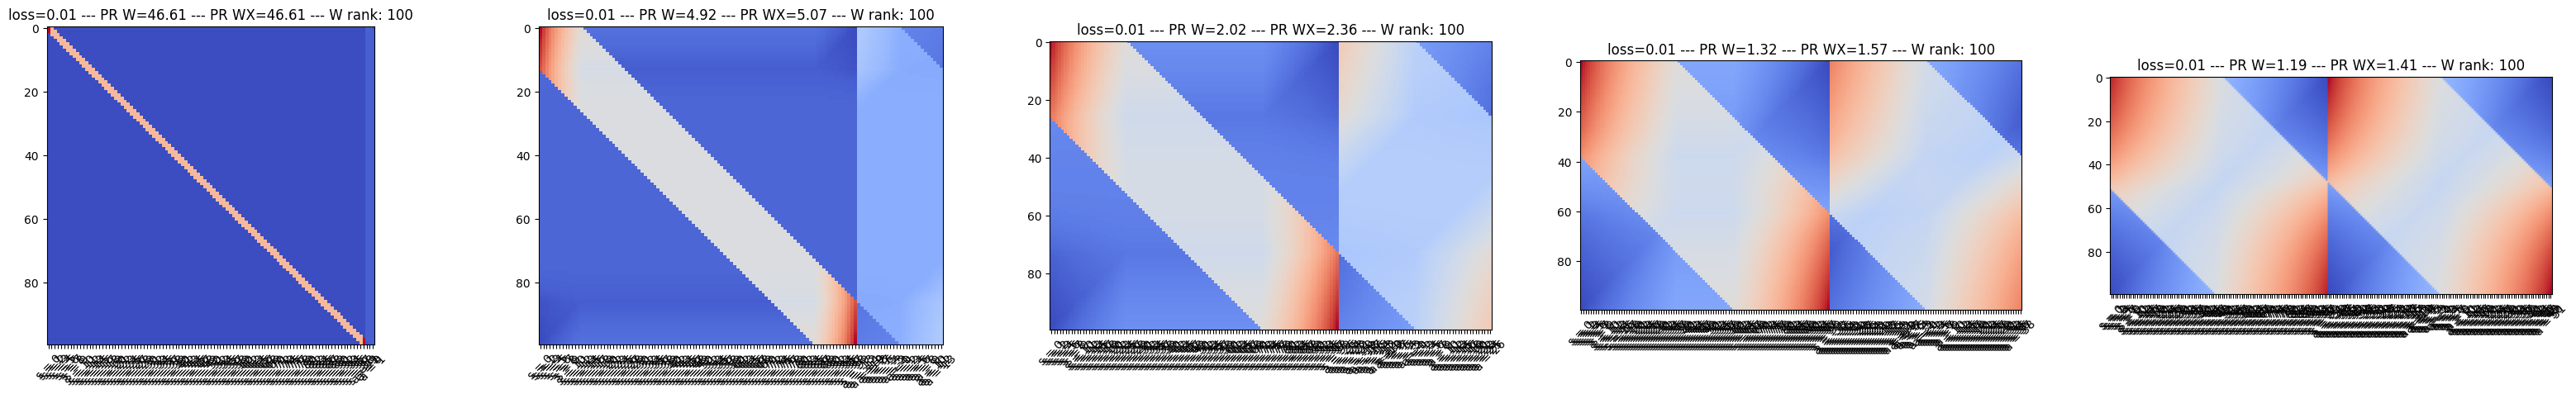

In [6]:
fig, axs = plt.subplots(1, len(X_l), figsize=(8*len(X_l),5))
for X_np, y_np, C, ax in zip(X_l, y_l, C_l, axs):
    Sigma31 = np.sum([yi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
    Sigma11 = np.sum([xi[:,None]@xi[None,:] for xi in X_np], 0)
    W = Sigma31@np.linalg.pinv(Sigma11)
    # if W_name == 'W_loremote
    #  = W
    ax.imshow(W, cmap='coolwarm')
    lamb = PCA().fit(X_np@W.T).explained_variance_
    PRWX = lamb.sum() ** 2 / (lamb ** 2).sum()
    lamb = PCA().fit(W).explained_variance_
    PR = lamb.sum() ** 2 / (lamb ** 2).sum()
    ax.set_title(f'loss={((((X_np@W.T)- y_np))**2).mean():.2f} --- PR W={PR:.2f} --- PR WX={PRWX:.2f} --- W rank: {np.linalg.matrix_rank(W, tol=np.sqrt(lamb[0])*(1/W.shape[0]))}')
    ax.set_xticks(np.arange(X_np.shape[1]), [f's = {i}' for i in range(loc_y.max()+1)]+[f'a = {i}' for i in range(-C.max_move, C.max_move+1)], rotation=45)
    ax.grid(False)

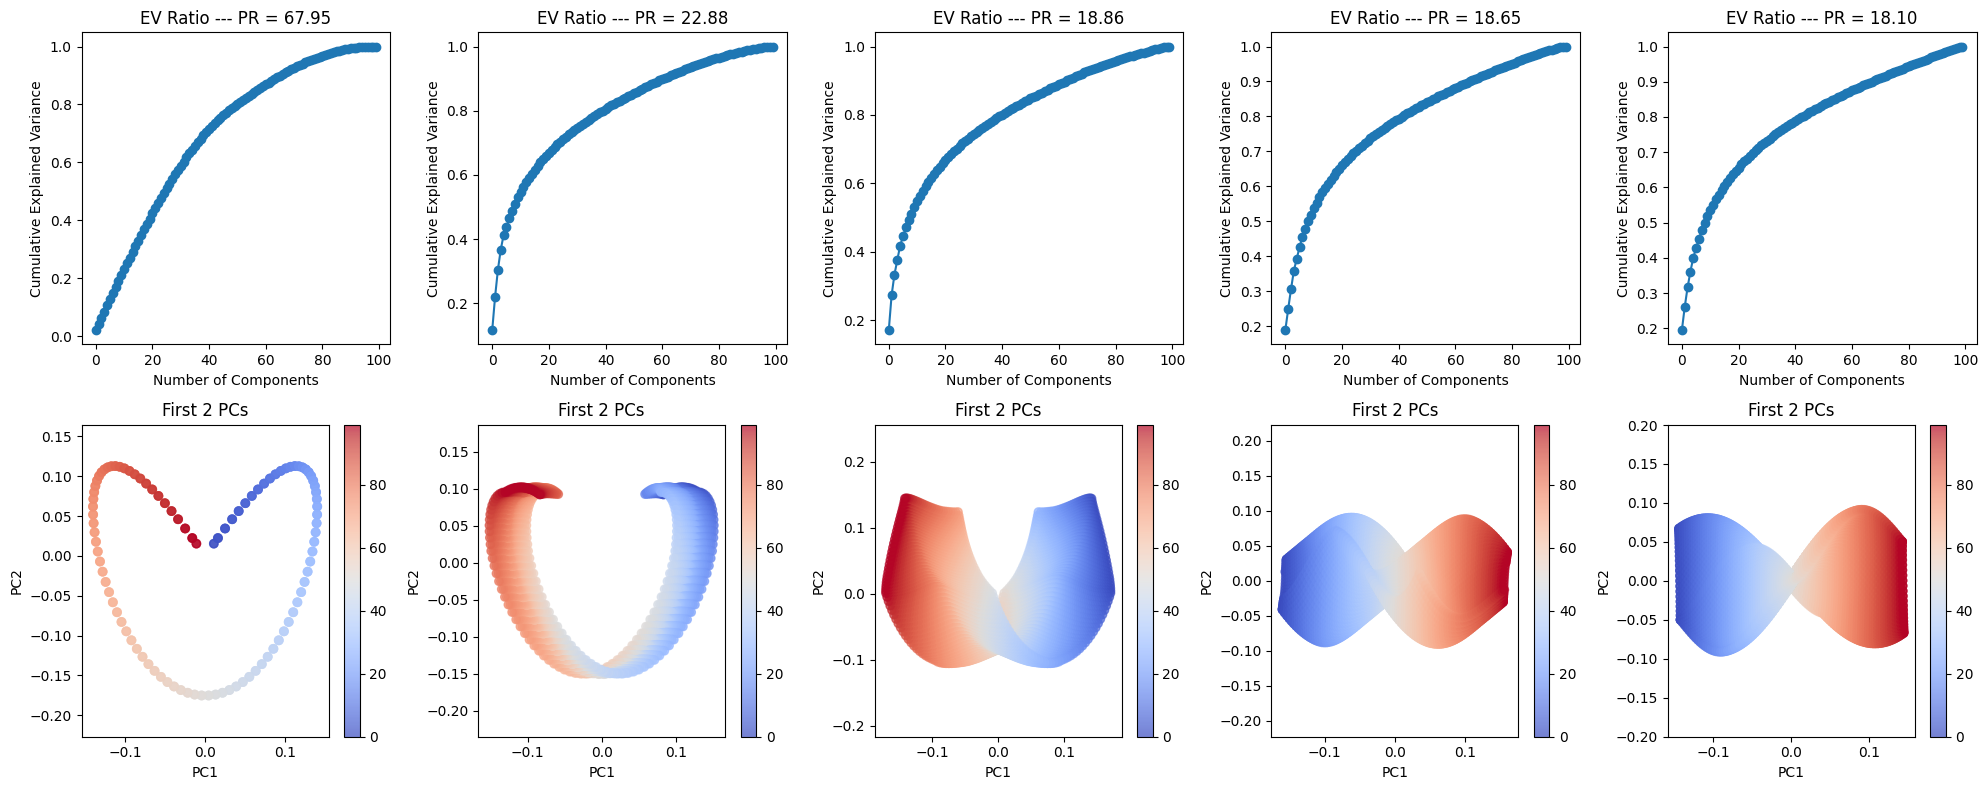

In [ ]:
# Create figure with subplots for each W matrix
# Create figure with subplots for each W matrix
fig, axs = plt.subplots(2, len(X_l), figsize=(4*len(X_l), 8))
axs = axs.T
for i, (X_np, y_np, C, loc_y) in enumerate(zip(X_l, y_l, C_l, loc_y_l)):
    Sigma31 = np.sum([yi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
    Sigma11 = np.sum([xi[:,None]@xi[None,:] for xi in X_np], 0)
    W = Sigma31@np.linalg.pinv(Sigma11)
    A, B = factorize_matrix(W, N=None)
    h_synthetic = X_np @ B.T
    
    # Fit PCA
    pca = PCA().fit(h_synthetic)
    X_reduced = pca.transform(h_synthetic)
    
    # Plot explained variance ratio
    axs[i,0].plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    PR = pca.explained_variance_.sum()**2/(pca.explained_variance_**2).sum()
    axs[i,0].set_xlabel('Number of Components')
    axs[i,0].set_ylabel('Cumulative Explained Variance')
    axs[i,0].set_title(f'EV Ratio --- PR = {PR:.2f}')
    
    # Plot first two PCs colored by location
    s = axs[i,1].scatter(X_reduced[:, 0], X_reduced[:, 1], c=loc_y, 
                        cmap='coolwarm', alpha=0.7)
    axs[i,1].set_xlabel('PC1')
    axs[i,1].set_ylabel('PC2')
    axs[i,1].set_title(f'First 2 PCs')
    fig.colorbar(s, ax=axs[i,1])
    axs[i,1].axis('equal')

plt.tight_layout()
plt.show()